# Estimating aliased spectra robustness

In [1]:
import traceback
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import cmocean
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

In [2]:
DATA_DIR          = '/Volumes/PortableSSD/diags_2024/'
SEGMENT_LENGTH_KM = 500.0
EXPERT_FILE       = f'swot_segments2D_{int(SEGMENT_LENGTH_KM)}km_demean.nc'
UNSMOOTHED_FILE   = f'swot_unsmoothed_aliased_{int(SEGMENT_LENGTH_KM)}km.nc'

#---------- Box parameters ------------------------
BOX_DEG = 2.0
MIN_SAMPLING_FRACTION = 0.15


In [3]:
ds_segments_ex = xr.open_dataset(DATA_DIR+EXPERT_FILE)
ds_segments_un = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE)
ds_segments_un = ds_segments_un.where((ds_segments_un.lat_mean<=60) & (ds_segments_un.lat_mean>=-60), drop=True)

#Removing bad data
recs_01   = ds_segments_un.sel(wavenumber=0.1,method='nearest')
id_flag = np.where(recs_01.total_psd.values<=3e-4)[0]
ds_segments_un   = ds_segments_un.isel(segment=id_flag)
print(f'Percentage of flagged segments: {(recs_01.segment.size-id_flag.size) / recs_01.segment.size * 100: .1f} %')

Percentage of flagged segments:  23.5 %


## Spectra comparison

In [4]:
k             = ds_segments_un['wavenumber'].values
direct_stack  = ds_segments_un['direct_psd']
aliased_stack = ds_segments_un['aliased_psd']
total_stack   = ds_segments_un['total_psd']

psd_ex_mean  = ds_segments_ex['psd'].mean('segment')
total_mean   = total_stack.mean('segment')
aliased_mean = aliased_stack.mean('segment')
direct_mean  = direct_stack.mean('segment')

direct_lo, direct_hi = np.nanpercentile(direct_stack, [5, 95], axis=0)
aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [5, 95], axis=0)
total_lo, total_hi = np.nanpercentile(total_stack, [5, 95], axis=0)

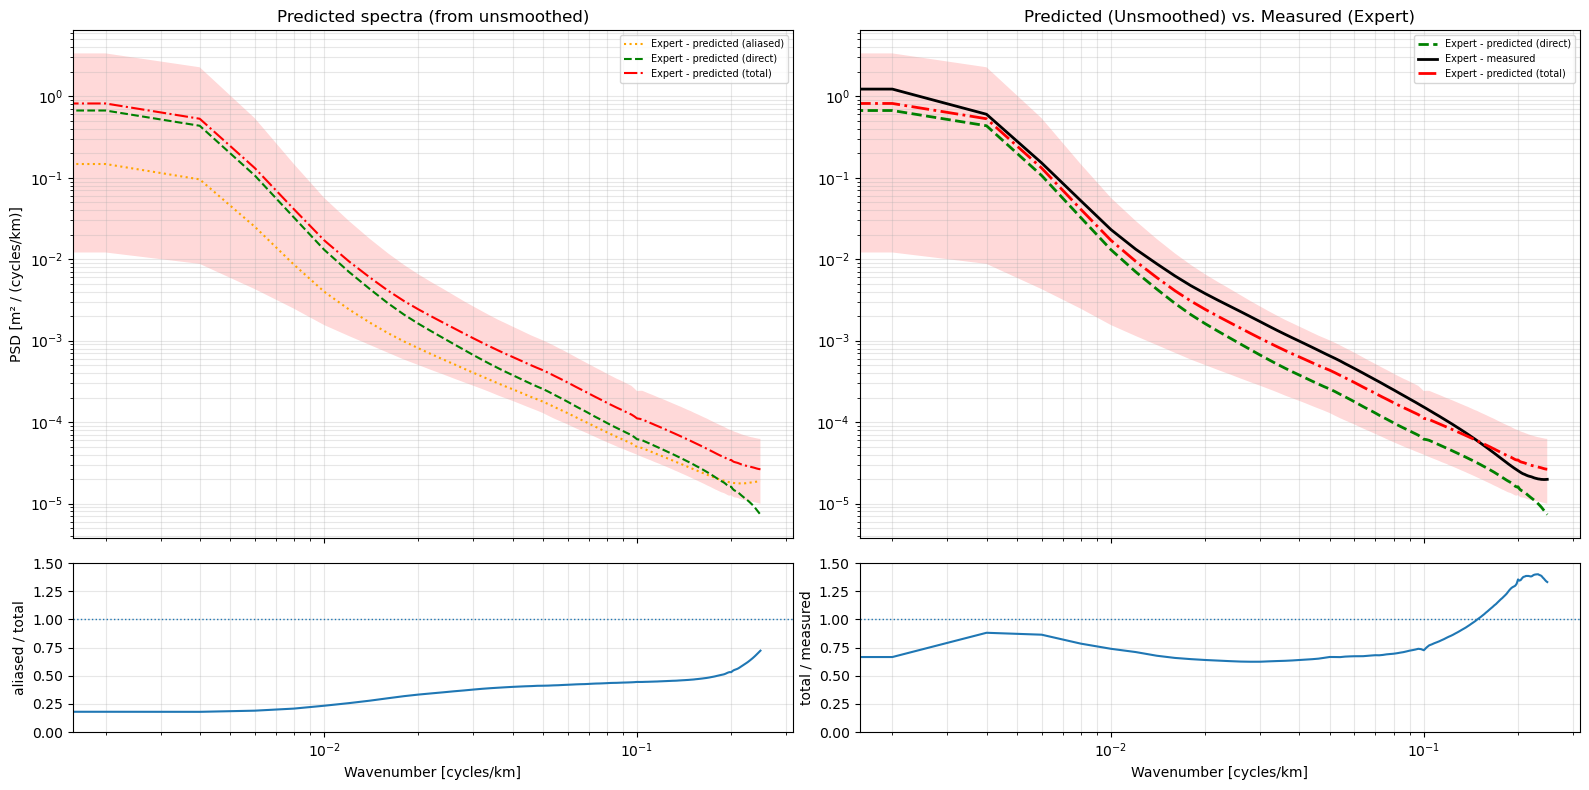

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
    
ax = axs[0,0]
ax.fill_between(k, total_lo, total_hi, color='r', alpha=0.15, lw=0)
ax.loglog(k, aliased_mean, c='orange', lw=1.5, ls=':', label=f'Expert - predicted (aliased)')
ax.loglog(k, direct_mean, c='g',lw=1.5, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, total_mean, c='r', lw=1.5, ls='-.', label=f'Expert - predicted (total)')


ax = axs[0,1]
ax.fill_between(k, total_lo, total_hi, color='r', alpha=0.15, lw=0)
ax.loglog(k, direct_mean, c='g', lw=2, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, psd_ex_mean, c='k', lw=2, label=f'Expert - measured')
ax.loglog(k, total_mean, c='r', lw=2, ls='-.', label=f'Expert - predicted (total)')

    
axs[1,0].semilogx(k, aliased_mean / total_mean, lw=1.5)
axs[1,1].semilogx(k, total_mean.values / psd_ex_mean.values, lw=1.5)

axs[0,0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0,0].grid(True, which='both', alpha=0.3)
axs[0,1].grid(True, which='both', alpha=0.3)
axs[0,0].legend(fontsize=7)
axs[0,1].legend(fontsize=7)

axs[1,0].set_ylabel('aliased / total')
axs[1,1].set_ylabel('total / measured')
for ax in axs[1,:]:
    ax.axhline(1.0, ls=':', lw=1)
    ax.set_xlabel('Wavenumber [cycles/km]')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(0.,1.5)

axs[0,0].set_title('Predicted spectra (from unsmoothed)')
axs[0,1].set_title('Predicted (Unsmoothed) vs. Measured (Expert)')
fig.tight_layout()

## Global maps

In [8]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      psd_var: str = 'psd',
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments[psd_var].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

import cartopy.feature as cfeature
import matplotlib.ticker as mticker

def plot_box(var: np.array, lon: np.array, lat: np.array,
             box_deg: float = None,
             projection: ccrs = ccrs.Robinson(), cmap: str = "viridis",
             figsize: tuple = (14, 7), fig = None, ax = None,
             title: str = "Number of observations per box", label: str = "Number of observations",
             norm: norm = None, vmin: float = None, vmax: float = None
            ):
    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    # Infer box size from the spacing of box centers if not given
    if box_deg is None:
        lat_diffs = np.diff(np.unique(np.round(lat, 6)))
        lon_diffs = np.diff(np.unique(np.round(lon, 6)))
        box_deg = np.min(np.concatenate([lat_diffs, lon_diffs]))

    # Reconstruct the regular grid of box centers
    lat_centers = np.arange(lat.min(), lat.max() + box_deg, box_deg)
    lon_centers = np.arange(lon.min(), lon.max() + box_deg, box_deg)

    lat_idx = np.round((lat - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = var

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])
    if ax==None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    if norm is not None:
        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), norm=norm)
    else:
        if vmin is None:
            vmin, vmax = np.nanmin(var), np.nanmax(var)

        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)
    ax.set_title(title)

    return fig, ax

In [9]:
boxes_ex = build_box_dataset(ds_segments_ex, box_deg=BOX_DEG, min_sampling_fraction=MIN_SAMPLING_FRACTION)
boxes_un_total = build_box_dataset(ds_segments_un, psd_var='total_psd', box_deg=BOX_DEG, min_sampling_fraction=MIN_SAMPLING_FRACTION)
boxes_un_aliased = build_box_dataset(ds_segments_un, psd_var='aliased_psd', box_deg=BOX_DEG, min_sampling_fraction=MIN_SAMPLING_FRACTION)

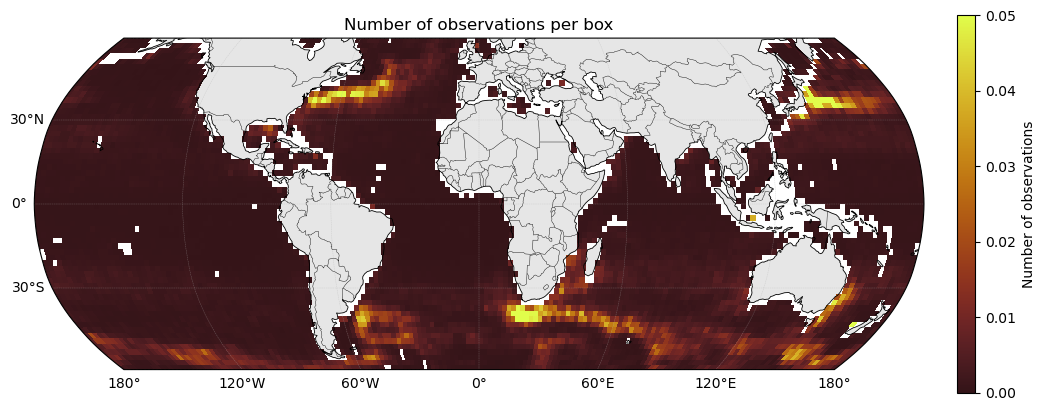

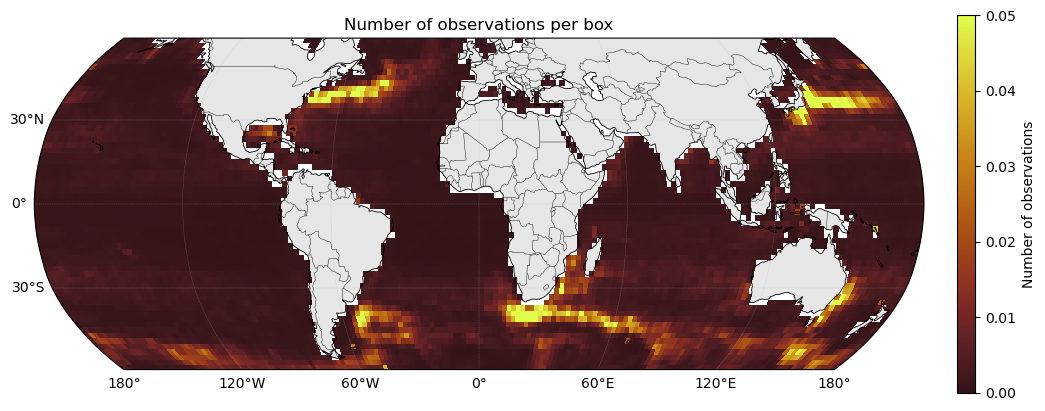

In [10]:
fig,ax = plot_box(boxes_un_total.mean_psd.integrate('wavenumber'),
                  boxes_un_total.lon_mean, boxes_un_total.lat_mean,
                 cmap=cmocean.cm.solar, vmax=5e-2,vmin=0)
ax.set_extent([-180,180,-60,60])

fig,ax = plot_box(boxes_ex.mean_psd.integrate('wavenumber'),
                  boxes_ex.lon_mean, boxes_ex.lat_mean,
                 cmap=cmocean.cm.solar, vmax=5e-2,vmin=0)
ax.set_extent([-180,180,-60,60])

In [11]:
matched_boxes = []
flags = []
for i in boxes_ex.box.values:
    _ = boxes_ex.sel(box=i)
    _un = boxes_un_total.where((boxes_un_total.lat_mean==_.lat_mean.values) & (boxes_un_total.lon_mean==_.lon_mean.values),drop=True).mean_psd
    if _un.shape[0]== 1:
        #flags.append((_.lat_mean.values, _.lon_mean.values))
        matched_boxes.append(i)
#print(np.unique(boxes_ex.lon_mean)- np.unique(boxes_ex.lon_mean))

In [12]:
matched_boxes_un = []
flags_2 = []
for i in boxes_un_total.box.values:
    _ = boxes_un_total.sel(box=i)
    _un = boxes_ex.where((boxes_ex.lat_mean==_.lat_mean.values) & (boxes_ex.lon_mean==_.lon_mean.values),drop=True).mean_psd
    if _un.shape[0]== 1:
        #flags_2.append((_.lat_mean.values, _.lon_mean.values))
        matched_boxes_un.append(i)

In [13]:
len(matched_boxes_un)

7176

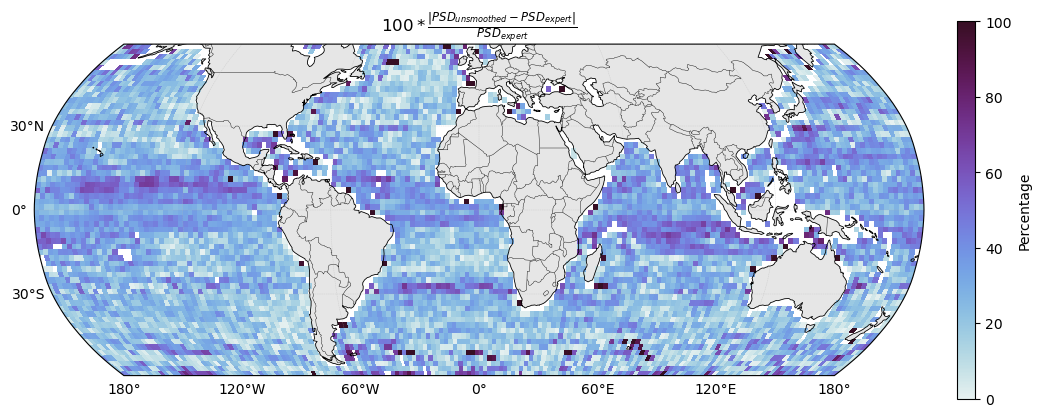

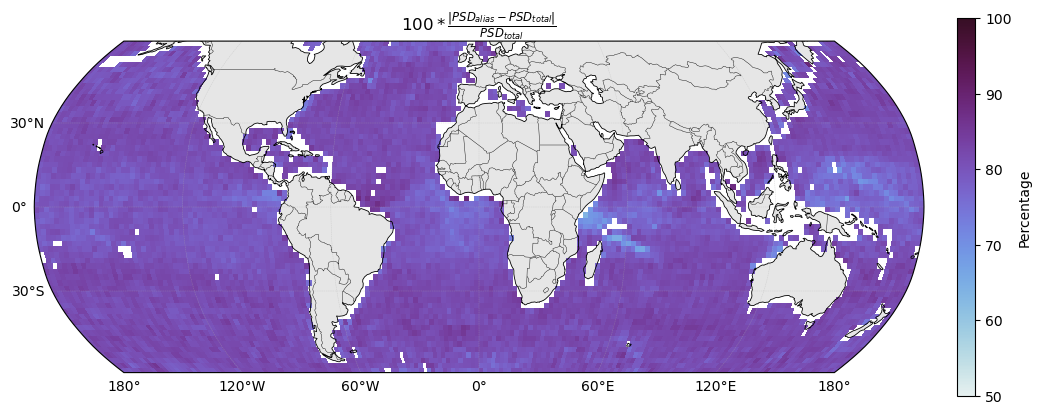

In [23]:
boxes_ex_matched = boxes_ex.sel(box=matched_boxes).sortby(['lat_mean','lon_mean'])
boxes_un_matched = boxes_un_total.sel(box=matched_boxes_un).sortby(['lat_mean','lon_mean'])

kmin,kmax = 1/1000,1/100
energy_ex = boxes_ex_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values
energy_un = boxes_un_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values

fig,ax = plot_box(np.abs(energy_un - energy_ex) / energy_ex*100,
                  boxes_un_matched.lon_mean, boxes_un_matched.lat_mean,
                 cmap=cmocean.cm.dense, vmax=100,vmin=0,
                  title=r"$100*\frac{\vert PSD_{unsmoothed} - PSD_{expert}\vert} {PSD_{expert}}$",
                  label='Percentage'
                )
ax.set_extent([-180,180,-60,60])


boxes_alias_matched = boxes_un_aliased.sel(box=matched_boxes_un).sortby(['lat_mean','lon_mean'])
boxes_total_matched = boxes_un_total.sel(box=matched_boxes_un).sortby(['lat_mean','lon_mean'])

kmin,kmax = 1/1000,1/100
energy_al = boxes_alias_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values
energy_un = boxes_un_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values

fig,ax = plot_box(np.abs(energy_al - energy_un) / energy_un*100,
                  boxes_un_matched.lon_mean, boxes_un_matched.lat_mean,
                 cmap=cmocean.cm.dense, vmax=100,vmin=50,
                  title=r"$100*\frac{\vert PSD_{alias} - PSD_{total}\vert} {PSD_{total}}$",
                  label='Percentage'
                )
ax.set_extent([-180,180,-60,60])

In [34]:
kmin,kmax = 1/1000,None
energy_ex = boxes_ex_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values
energy_un = boxes_un_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values

print(f"Average difference between predicted and measured expert product (for all scales) is {(np.abs(energy_un - energy_ex) / energy_ex).mean()*100: .1f}% of the expert product")

kmin,kmax = 1/1000,1/100
energy_ex = boxes_ex_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values
energy_un = boxes_un_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values

print(f"Average difference between predicted and measured expert product (for scales between 100km and 1000km) is {(np.abs(energy_un - energy_ex) / energy_ex*100).mean(): .1f}% of the expert product")

kmin,kmax = 1/100,None
energy_ex = boxes_ex_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values
energy_un = boxes_un_matched.mean_psd.sel(wavenumber=slice(kmin,kmax)).integrate('wavenumber').values

print(f"Average difference between predicted and measured expert product (for scales smaller than 100km) is {(np.abs(energy_un - energy_ex) / energy_ex*100).mean(): .1f}% of the expert product")


Average difference between predicted and measured expert product (for all scales) is  27.6% of the expert product
Average difference between predicted and measured expert product (for scales between 100km and 1000km) is  29.5% of the expert product
Average difference between predicted and measured expert product (for scales smaller than 100km) is  14.8% of the expert product
